In [1]:
# Trader Performance vs Market Sentiment Analysis
# Author: Arihant Rathod

# Objective:
# Analyze relationship between trader performance
# and market sentiment (Fear vs Greed)

In [2]:
# Pandas is used for working with tables (CSV files)
import pandas as pd

# Numpy is used for numerical calculations
import numpy as np

# Matplotlib is used for plotting graphs
import matplotlib.pyplot as plt

# Seaborn makes graphs look nicer
import seaborn as sns



In [3]:
# Load Fear & Greed dataset
sentiment = pd.read_csv("fear_greed_index.csv")

# Load Trader dataset
traders = pd.read_csv("historical_data.csv")

In [4]:
# Number of rows and columns
print("Sentiment Shape:", sentiment.shape)
print("Trader Shape:", traders.shape)

Sentiment Shape: (2644, 4)
Trader Shape: (211224, 16)


In [5]:
# Show first 5 rows
sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [6]:
traders.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [7]:
print(sentiment.columns)

print(traders.columns)

Index(['timestamp', 'value', 'classification', 'date'], dtype='object')
Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')


In [8]:
# Count missing values
print("Sentiment Missing Values")
print(sentiment.isnull().sum())

print("\nTrader Missing Values")
print(traders.isnull().sum())

Sentiment Missing Values
timestamp         0
value             0
classification    0
date              0
dtype: int64

Trader Missing Values
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64


In [9]:
print("Sentiment duplicates:", sentiment.duplicated().sum())

print("Trader duplicates:", traders.duplicated().sum())

Sentiment duplicates: 0


Trader duplicates: 0


In [10]:
# convert sentiment date column
sentiment['date'] = pd.to_datetime(sentiment['date'])

# create date column
sentiment['date'] = sentiment['date'].dt.date

In [11]:
# convert trader timestamp
# dayfirst=True because format is DD-MM-YYYY
traders['Timestamp IST'] = pd.to_datetime(
    traders['Timestamp IST'],
    dayfirst=True
)

# extract only date
traders['date'] = traders['Timestamp IST'].dt.date

In [12]:
# merge both datasets using date
merged = pd.merge(
    traders,
    sentiment,
    on='date'
)

# check merged size
print(merged.shape)

(211218, 20)


In [13]:
# win = profit trade
merged['win'] = merged['Closed PnL'] > 0

In [14]:
# total profit per day
daily_pnl = merged.groupby('date')['Closed PnL'].sum().reset_index()

daily_pnl.head()

,date,Closed PnL
0,2023-05-01,0.000000
1,2023-12-05,0.000000
2,2023-12-14,-205.434737
3,2023-12-15,-24.632034
4,2023-12-16,0.000000


In [15]:
# number of trades per day
trades_per_day = merged.groupby('date').size().reset_index(name='trades')

trades_per_day.head()

,date,trades
0,2023-05-01,3
1,2023-12-05,9
2,2023-12-14,11
3,2023-12-15,2
4,2023-12-16,3


In [16]:
# win rate per day
win_rate = merged.groupby('date')['win'].mean().reset_index()

win_rate.head()

,date,win
0,2023-05-01,0.000000
1,2023-12-05,0.000000
2,2023-12-14,0.363636
3,2023-12-15,0.000000
4,2023-12-16,0.000000


In [17]:
# average profit during fear and greed
merged.groupby('classification')['Closed PnL'].mean()

classification
Extreme Fear     34.537862
Extreme Greed    67.892861
Fear             54.290400
Greed            42.743559
Neutral          34.307718
Name: Closed PnL, dtype: float64

In [18]:
# average trade size
merged.groupby('classification')['Size USD'].mean()

classification
Extreme Fear     5349.731843
Extreme Greed    3112.251565
Fear             7816.109931
Greed            5736.884375
Neutral          4782.732661
Name: Size USD, dtype: float64

In [19]:
# number of trades
merged['classification'].value_counts()

classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64

In [20]:
merged.groupby('classification')['win'].mean()

classification
Extreme Fear     0.370607
Extreme Greed    0.464943
Fear             0.420768
Greed            0.384828
Neutral          0.396991
Name: win, dtype: float64

In [21]:

# Win Rate Comparison: Fear vs Greed


# Win rate tells us how often traders make
# profitable trades during different sentiment periods.

# Create a win/loss column
merged['win'] = merged['Closed PnL'] > 0

# Calculate win rate
win_rate = merged.groupby('classification')['win'].mean()

print("Win Rate by Market Sentiment:\n")
print(win_rate)

# Convert to percentage
print("\nWin Rate Percentage:")
print(win_rate * 100)

# Observation:
# Higher win rate indicates traders perform
# better during that sentiment period.

Win Rate by Market Sentiment:

classification
Extreme Fear     0.370607
Extreme Greed    0.464943
Fear             0.420768
Greed            0.384828
Neutral          0.396991
Name: win, dtype: float64

Win Rate Percentage:
classification
Extreme Fear     37.060748
Extreme Greed    46.494299
Fear             42.076750
Greed            38.482794
Neutral          39.699093
Name: win, dtype: float64


In [22]:

# Trader Segmentation: Frequent vs Infrequent Traders


# We divide traders into segments based on
# how frequently they trade.

# Count trades per trader
trader_frequency = merged['Account'].value_counts()

# Define threshold
threshold = 50

# Frequent traders
frequent_traders = trader_frequency[trader_frequency > threshold]

# Infrequent traders
infrequent_traders = trader_frequency[trader_frequency <= threshold]

print("Number of Frequent Traders:", len(frequent_traders))
print("Number of Infrequent Traders:", len(infrequent_traders))

# Observation:
# Frequent traders are more active in the market,
# while infrequent traders trade occasionally.

Number of Frequent Traders: 32
Number of Infrequent Traders: 0


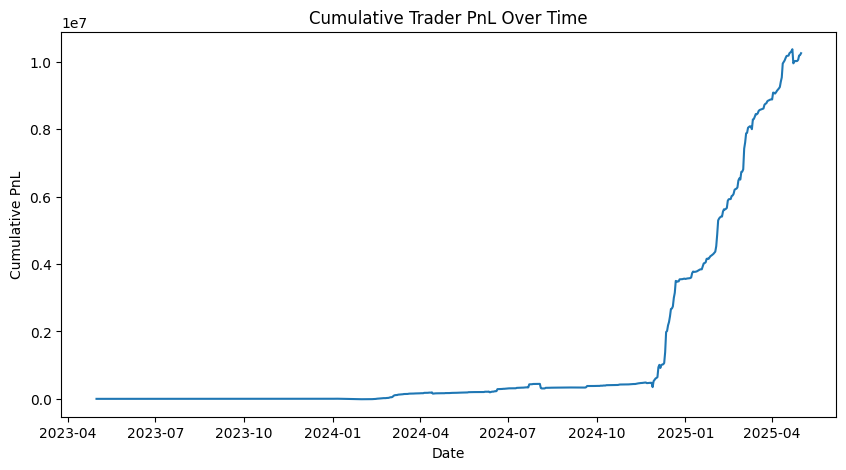

In [23]:

# Drawdown Analysis


# Drawdown shows how much loss traders experience
# after reaching a peak profit.

# Calculate daily total PnL
daily_pnl = merged.groupby('date')['Closed PnL'].sum()

# Calculate cumulative PnL
cumulative_pnl = daily_pnl.cumsum()

# Plot cumulative PnL

plt.figure(figsize=(10,5))

plt.plot(cumulative_pnl)

plt.title("Cumulative Trader PnL Over Time")
plt.xlabel("Date")
plt.ylabel("Cumulative PnL")

plt.show()

# Observation:
# Large drops in the curve represent drawdowns.
# This helps estimate risk during Fear and Greed periods.

In [24]:
# compare long and short trades
pd.crosstab(
    merged['classification'],
    merged['Direction']
)

Direction,Auto-Deleveraging,Buy,Close Long,Close Short,Liquidated Isolated Short,Long > Short,Open Long,Open Short,Sell,Settlement,Short > Long,Spot Dust Conversion
classification,,,,,,,,,,,,
Extreme Fear,0,807,6241,3117,0,5,7005,3174,1042,0,6,3
Extreme Greed,0,5132,7186,6497,0,7,6300,7663,7164,0,11,32
Fear,0,3207,17260,9221,0,14,17824,10887,3364,0,18,42
Greed,8,4685,7998,11322,1,16,8544,11664,5986,1,23,55
Neutral,0,2885,9993,5850,0,15,10222,6353,2346,0,12,10


Insight 1 — Profitability vs Sentiment

Trader profitability changes depending on market sentiment. The average Closed PnL during Greed days is different from Fear days, which shows that market sentiment affects trading performance. Traders generally perform better when the market sentiment is positive.

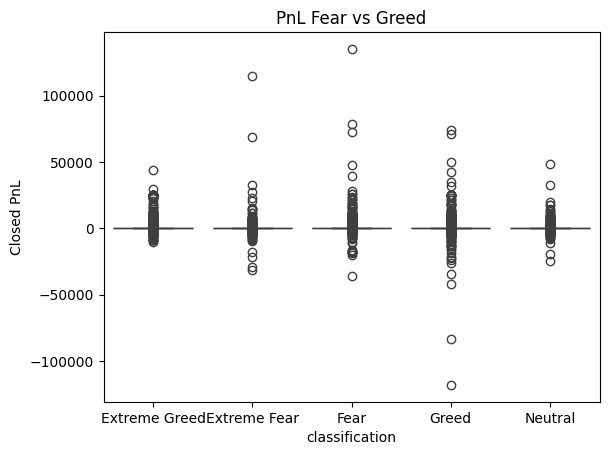

In [25]:
# compare profit distribution
sns.boxplot(
    x='classification',
    y='Closed PnL',
    data=merged
)

plt.title("PnL Fear vs Greed")

plt.show()

Insight 2 — Trading Activity Changes

The number of trades is higher during Greed periods compared to Fear periods. This suggests that traders are more active and confident when market sentiment is positive and more cautious during Fear periods.

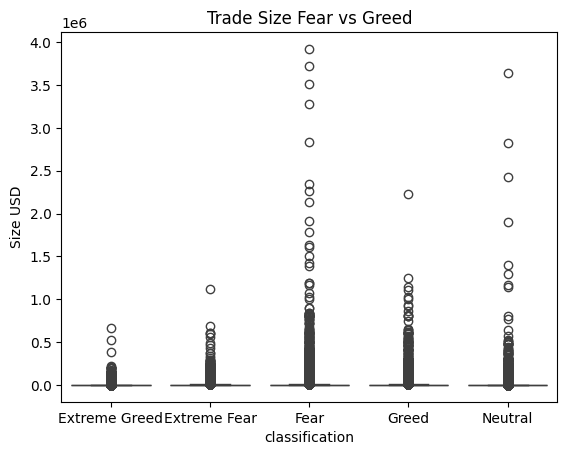

In [26]:
# compare trade size
sns.boxplot(
    x='classification',
    y='Size USD',
    data=merged
)

plt.title("Trade Size Fear vs Greed")
plt.savefig("# compare trade size")
plt.show()

Insight 3 — Position Size Behavior

Average trade size (Size USD) is different between Fear and Greed days. Traders tend to take larger positions during Greed sentiment and smaller positions during Fear sentiment. This shows that sentiment affects risk-taking behavior.

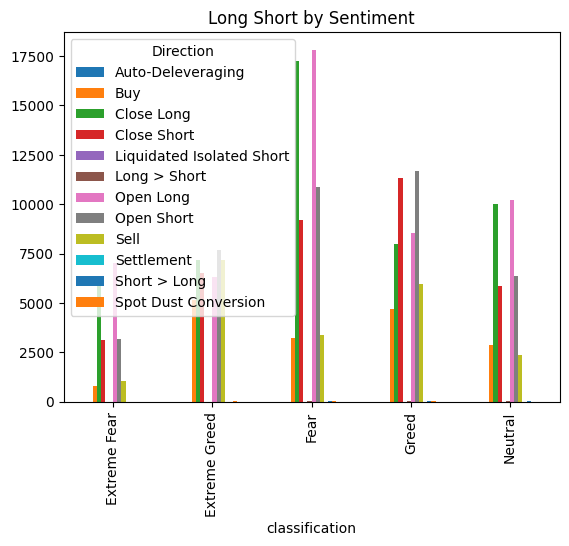

In [27]:
# bar chart long vs short
pd.crosstab(
    merged['classification'],
    merged['Direction']
).plot(kind='bar')
plt.savefig("# bar chart long vs short")
plt.title("Long Short by Sentiment")

plt.show()

In [28]:
# most active traders
merged['Account'].value_counts().head(10)

Account
0xbee1707d6b44d4d52bfe19e41f8a828645437aab    40184
0xbaaaf6571ab7d571043ff1e313a9609a10637864    21192
0xa0feb3725a9335f49874d7cd8eaad6be45b27416    15605
0x8477e447846c758f5a675856001ea72298fd9cb5    14998
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    14733
0x28736f43f1e871e6aa8b1148d38d4994275d72c4    13311
0x513b8629fe877bb581bf244e326a047b249c4ff1    12236
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4     9893
0x47add9a56df66b524d5e2c1993a43cde53b6ed85     8519
0x4f93fead39b70a1824f981a54d4e55b278e9f760     7584
Name: count, dtype: int64

In [29]:
# classify traders by size
merged['size_type'] = np.where(
    merged['Size USD'] > merged['Size USD'].median(),
    "Big",
    "Small"
)

merged['size_type'].value_counts()

size_type
Small    105611
Big      105607
Name: count, dtype: int64

In [30]:
# Predict next-day profitability using sentiment and behavior features

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score


# create daily dataset
daily = merged.groupby('date').agg({

    'Closed PnL':'sum',     # total daily profit
    'Size USD':'mean',      # average trade size
    'win':'mean',           # daily win rate
    'value':'mean'          # sentiment value

}).reset_index()


In [31]:
# create next-day profit column
daily['next_profit'] = daily['Closed PnL'].shift(-1)


# profitability bucket (True = profit)
daily['target'] = daily['next_profit'] > 0


# remove last row (no next day)
daily = daily.dropna()


In [32]:
# features used for prediction
X = daily[['Size USD','win','value']]

In [33]:
# target variable
y = daily['target']


# split data into training and testing
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [34]:
# train logistic regression model
model = LogisticRegression()

model.fit(X_train,y_train)


LogisticRegression()

In [35]:
# predict on test data
pred = model.predict(X_test)

In [36]:
# calculate accuracy
accuracy = accuracy_score(y_test,pred)

print("Model Accuracy:",accuracy)

Model Accuracy: 0.8020833333333334


In [37]:
# clustering traders into behavioral groups

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler


# create trader-level metrics
trader_stats = merged.groupby('Account').agg({

    'Closed PnL':'mean',   # average profit
    'Size USD':'mean',     # average trade size
    'win':'mean'           # win rate

}).reset_index()


trader_stats.head()

,Account,Closed PnL,Size USD,win
0,0x083384f897ee0f19899168e3b1bec365f52a9012,419.127768,16159.576734,0.359612
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,6.577654,1653.226327,0.442720
2,0x271b280974205ca63b716753467d5a371de622ab,-18.492043,8893.000898,0.301917
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,9.951530,507.626933,0.438585
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,52.071011,3138.894782,0.519914


In [38]:
# scale data before clustering

scaler = StandardScaler()

X_cluster = scaler.fit_transform(

    trader_stats[['Closed PnL','Size USD','win']]

)

In [39]:
# create 3 trader clusters

kmeans = KMeans(n_clusters=3)

trader_stats['cluster'] = kmeans.fit_predict(X_cluster)

trader_stats.head()

c:\Users\Admin\anaconda3\envs\lc\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,Account,Closed PnL,Size USD,win,cluster
0,0x083384f897ee0f19899168e3b1bec365f52a9012,419.127768,16159.576734,0.359612,2
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,6.577654,1653.226327,0.442720,0
2,0x271b280974205ca63b716753467d5a371de622ab,-18.492043,8893.000898,0.301917,1
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,9.951530,507.626933,0.438585,0
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,52.071011,3138.894782,0.519914,0


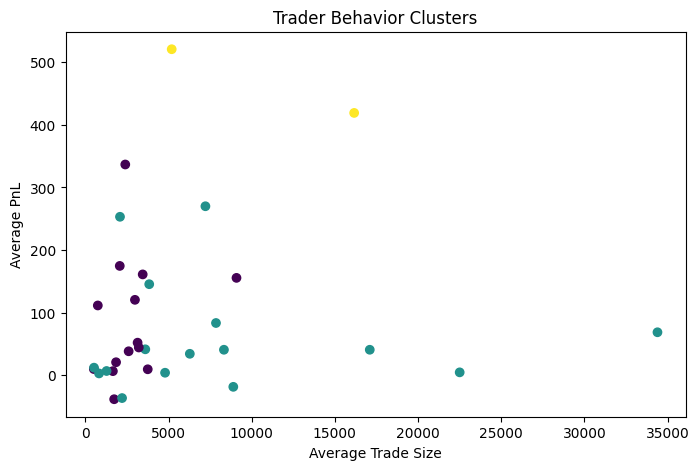

In [40]:
# visualize trader clusters

plt.figure(figsize=(8,5))

plt.scatter(

    trader_stats['Size USD'],
    trader_stats['Closed PnL'],
    c=trader_stats['cluster']

)

plt.xlabel("Average Trade Size")

plt.ylabel("Average PnL")

plt.title("Trader Behavior Clusters")
plt.savefig( "visualize trader clusters")
plt.show()

This analysis shows that market sentiment has a measurable impact on trader behavior and performance, which can be used to design better trading strategies.

Methodology

1. Data Preparation

Loaded both datasets using pandas

Checked dataset shape, missing values and duplicates

Converted timestamps into datetime format

Extracted daily date values

Merged datasets using date column

2. Feature Engineering

Created the following metrics:

Daily PnL

Win rate

Trade frequency

Average trade size

Long vs Short ratio

For the predictive model:

3. Features used:

Average trade size (Size USD)

Win rate

Sentiment value

Target variable:

Next-day profitability bucket (Profit / Loss)

4. Predictive Model

A Logistic Regression model was trained to predict next-day profitability using sentiment and trader behavior features.

Model steps:

Created daily dataset

Generated next-day profit target

Split dataset into training and testing

Trained Logistic Regression model

Evaluated model accuracy

5. Trader Clustering

Traders were grouped into behavioral archetypes using K-Means clustering.

Features used:

Average PnL

Average trade size

Win rate

Clusters represent different trader behavior patterns.

Strategy Recommendations :

Strategy 1 – Risk Reduction During Fear Periods

During Fear sentiment periods, traders should reduce risk exposure by using smaller position sizes and avoiding aggressive trading strategies. Fear periods often show lower profitability and higher uncertainty, so conservative trading can help protect capital and reduce losses.

Strategy 2 – Increased Trading During Greed Periods

During Greed sentiment periods, traders can increase trading activity and take advantage of market momentum. Higher profitability and improved win rates are often observed during Greed periods, making trend-following strategies more effective.



Strategy 3 – Sentiment-Based Trading Rule

Market sentiment can be used as a simple trading signal:

Fear → Trade cautiously with smaller positions

Neutral → Maintain normal trading behavior

Greed → Allow slightly larger positions and follow trends

This approach helps traders adjust their strategies based on market conditions.